In [84]:
import csv
import matplotlib.pyplot as plt

In [85]:
def load_data(file_path):
    x, y = [], []
    with open(file_path, mode='r') as file:
        reader = csv.reader(file)
        for row in reader:
            x.append(float(row[0]))
            y.append(float(row[1]))
    return x, y

In [86]:
x, y = load_data('lr.csv')

print(f"Loaded {len(x)} data points.")

Loaded 5 data points.


In [87]:
def linear_regression(x, y, lr=0.0001, epochs=100, threshold=1e-6):
    w0 = 0.0
    w1 = 1.0
    n = len(x)
    losses = []

    print("Epoch, w1, w0, Loss")

    for i in range(epochs):
        grad_w0 = 0.0
        grad_w1 = 0.0
        total_loss = 0.0

        for j in range(n):
            prediction = w1 * x[j] + w0
            error = prediction - y[j]

            grad_w0 += error
            grad_w1 += error * x[j]
            total_loss += (error ** 2)

        grad_w0 /= n
        grad_w1 /= n
        current_loss = total_loss / (2 * n)
        losses.append(current_loss)

        w0 = w0 - lr * grad_w0
        w1 = w1 - lr * grad_w1

        if i % 10 == 0:
            print(i, ",", round(w1, 4), ",", round(
                w0, 4), ",", round(current_loss, 4))

        if abs(grad_w0) < threshold and abs(grad_w1) < threshold:
            break

    return w1, w0, losses

In [88]:
w1, w0, losses = linear_regression(x, y)

Epoch, w1, w0, Loss
0 , 1.265 , 0.0059 , 1772.5
10 , 2.0426 , 0.0324 , 326.8331
20 , 2.0911 , 0.0462 , 321.0075
30 , 2.0939 , 0.0593 , 320.8165
40 , 2.0939 , 0.0723 , 320.6477
50 , 2.0937 , 0.0853 , 320.4791
60 , 2.0934 , 0.0982 , 320.3106
70 , 2.0932 , 0.1112 , 320.1421
80 , 2.093 , 0.1242 , 319.9738
90 , 2.0928 , 0.1372 , 319.8055


In [89]:
def run_experiment(x, y, lr, epochs=3000, threshold=1e-9):
    w0 = 0.0
    w1 = 1.0
    n = len(x)
    losses = []
    for i in range(epochs):
        grad_w0 = 0.0
        grad_w1 = 0.0
        total_loss = 0.0
        for j in range(n):
            prediction = w1 * x[j] + w0
            error = prediction - y[j]
            grad_w0 += error
            grad_w1 += error * x[j]
            total_loss += (error ** 2)
        grad_w0 /= n
        grad_w1 /= n
        current_loss = total_loss / (2 * n)
        losses.append(current_loss)
        w0 = w0 - lr * grad_w0
        w1 = w1 - lr * grad_w1
        if abs(grad_w0) < threshold and abs(grad_w1) < threshold:
            break
    return w1, w0, losses

learning_rates = [0.000005, 0.00005, 0.0001, 0.0004]
epochs = 3000
results = {}

print(f"{'LR':<12} {'w1':>8} {'w0':>8} {'Final Loss':>12}")
for lr in learning_rates:
    w1_r, w0_r, loss_history = run_experiment(x, y, lr=lr, epochs=epochs)
    results[lr] = {'w1': w1_r, 'w0': w0_r, 'losses': loss_history}
    print(f"{lr:<12} {w1_r:>8.4f} {w0_r:>8.4f} {loss_history[-1]:>12.4f}")

LR                 w1       w0   Final Loss
5e-06          2.0914   0.2136     318.7988
5e-05          2.0616   1.9298     296.9795
0.0001         2.0298   3.7645     274.5358
0.0004         1.8637  13.3363     172.2299


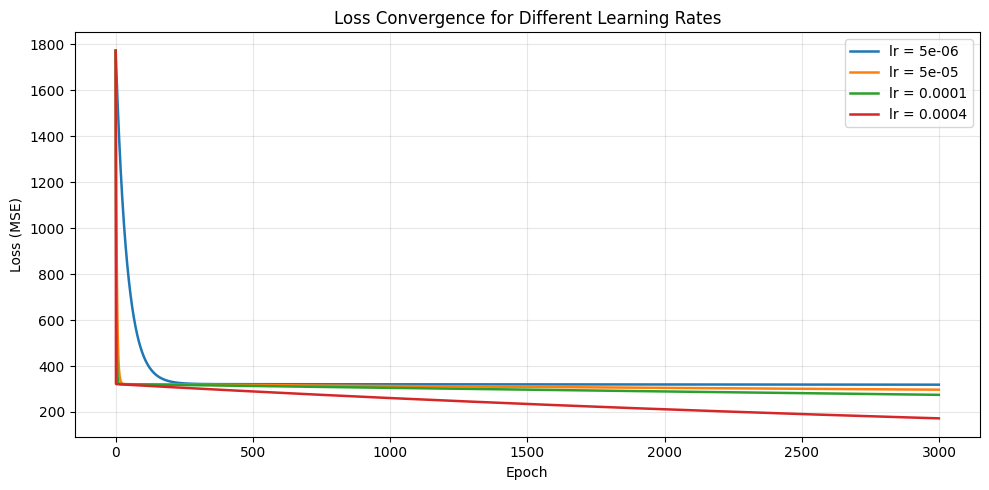

In [90]:
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

plt.figure(figsize=(10, 5))
for i, (lr, data) in enumerate(results.items()):
    plt.plot(data['losses'], label=f'lr = {lr}', color=colors[i], linewidth=1.8)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss Convergence for Different Learning Rates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

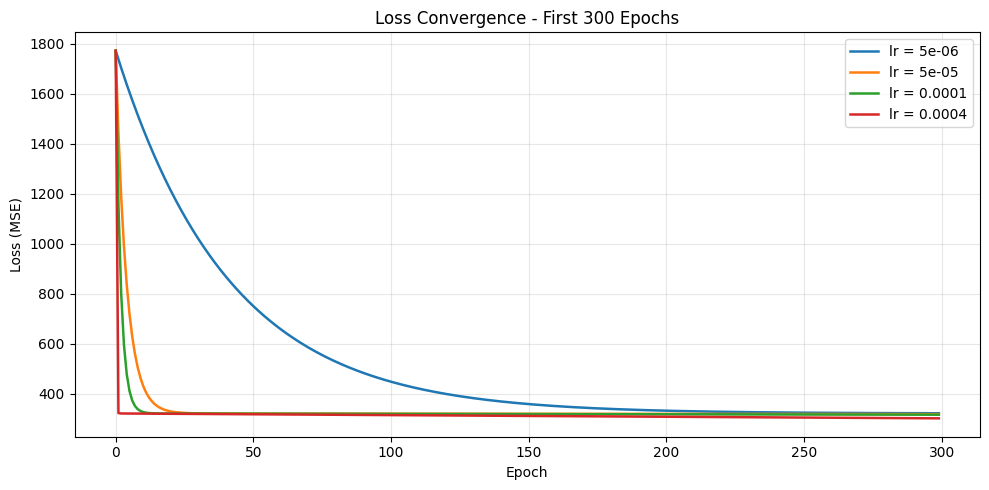

In [91]:
plt.figure(figsize=(10, 5))
for i, (lr, data) in enumerate(results.items()):
    plt.plot(data['losses'][:300], label=f'lr = {lr}', color=colors[i], linewidth=1.8)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss Convergence - First 300 Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves_early.png', dpi=150, bbox_inches='tight')
plt.show()

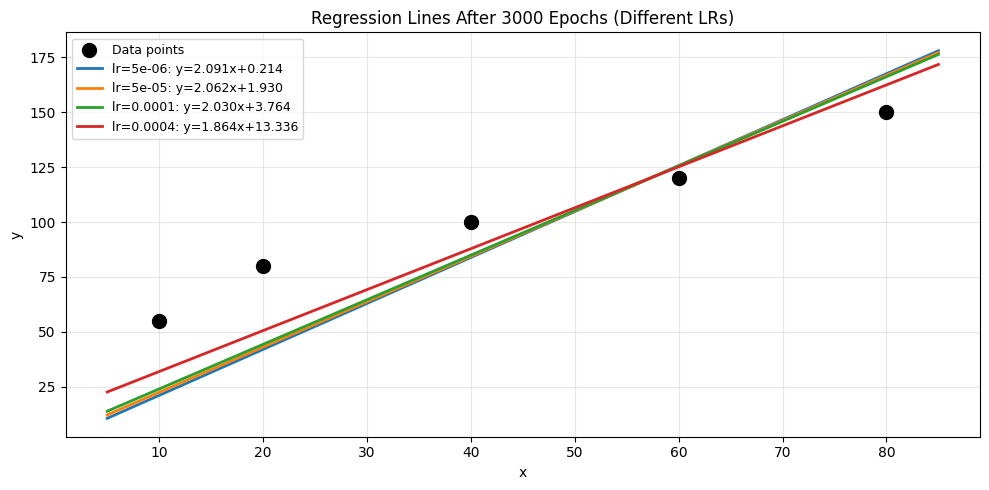

In [92]:
x_plot = [min(x) - 5, max(x) + 5]

plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='black', s=100, zorder=6, label='Data points')
for i, (lr, data) in enumerate(results.items()):
    y_plot = [data['w1'] * xi + data['w0'] for xi in x_plot]
    plt.plot(x_plot, y_plot, color=colors[i], linewidth=2,
             label=f'lr={lr}: y={data["w1"]:.3f}x+{data["w0"]:.3f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Regression Lines After {epochs} Epochs (Different LRs)')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('regression_lines_comparison.png', dpi=150, bbox_inches='tight')
plt.show()